# 🔒 Privacy Risk Scorer
### *How aggressively do websites track you? Let's find out.*

---

👋 **Welcome!** This notebook walks you through building a **Privacy Risk Scorer** from scratch.

We'll use real data from [WhoTracks.me](https://whotracks.me/) — a public dataset that measures how 10,000 popular websites behave when you visit them.

By the end, every website will have a **score from 0 to 100** that tells you how aggressively it tracks users.

---

### 🗺️ What we'll do — step by step

```
STEP 1 → Download the data from the internet
STEP 2 → Load it and take a first look
STEP 3 → Understand what each column means
STEP 4 → Clean up messy / useless columns
STEP 5 → Explore the data visually (charts!)
STEP 6 → Build the privacy scoring formula
```

---

> 💡 **How to use this notebook**
> - Run cells **top to bottom** — each one builds on the previous
> - Every cell has a comment explaining **what it does and why**
> - Don't worry if a cell has lots of output — scroll past it and keep going!


---

## 📦 Step 0 — Load the Tools

Before anything else, we import the Python libraries we'll use throughout this notebook.

Think of this like unpacking your toolbox before starting a project.

| Library | What it does |
|---------|-------------|
| `pandas` | Reads, organises, and manipulates data tables |
| `numpy` | Fast math on numbers (averages, square roots, etc.) |
| `matplotlib` | Draws charts and graphs |
| `seaborn` | Makes prettier charts on top of matplotlib |


In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# Import every library we need — all in one place so nothing breaks later
# ─────────────────────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings("ignore")   # hide harmless warnings that clutter output

import numpy  as np                 # math operations
import pandas as pd                 # data tables

import matplotlib.pyplot as plt    # drawing charts
import seaborn           as sns     # prettier charts

# ── Make charts look good and consistent throughout the notebook ──────────────
plt.rcParams.update({
    "figure.facecolor" : "#0d1117",   # dark background
    "axes.facecolor"   : "#161b22",
    "axes.edgecolor"   : "#30363d",
    "axes.labelcolor"  : "#e6edf3",
    "text.color"       : "#e6edf3",
    "xtick.color"      : "#8b949e",
    "ytick.color"      : "#8b949e",
    "grid.color"       : "#21262d",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.6,
    "figure.dpi"       : 110,
})

pd.set_option("display.max_columns", 35)          # show all columns in tables
pd.set_option("display.float_format", "{:.4f}".format)  # 4 decimal places

SEED = 42   # fixed seed so random samples are reproducible

print("✅  All tools loaded and ready!")


✅  All tools loaded and ready!


---

## 📥 Step 1 — Download the Data

The data lives on a public Amazon S3 bucket maintained by [WhoTracks.me](https://whotracks.me/).

**What is WhoTracks.me?**
> Millions of Ghostery browser extension users voluntarily share what tracking they see on websites. WhoTracks.me aggregates this into monthly snapshots — one row per website, summarising its tracking behaviour.

**What we're downloading:**
- 📅 Month: **April 2026**
- 🌍 Scope: **Global** (worldwide average, not country-specific)
- 📊 Size: ~15 MB

> ⚠️ **Only run this once!** The `--exact-timestamps` flag means it won't re-download files you already have.


In [ ]:
# Install the AWS command-line tool (needed to download from S3)
# The --quiet flag hides the installation logs to keep output clean
!pip install awscli --quiet
print("✅  AWS CLI ready")


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Download the April 2026 global snapshot from WhoTracks.me
#
# What each flag means:
#   --no-sign-request   → the bucket is public, no account needed
#   --exact-timestamps  → skip files we already downloaded (safe to re-run)
#   --quiet             → don't show every file being downloaded
# ─────────────────────────────────────────────────────────────────────────────
!aws s3 sync s3://data.whotracks.me/2026-04/global/ ./whotracks_2026/ \
    --no-sign-request  \
    --exact-timestamps \
    --quiet

print("✅  Download complete!  Files saved in → ./whotracks_2026/")

# Confirm the files are there
import os
files = os.listdir("./whotracks_2026/")
print(f"   Found {len(files)} file(s): {files}")


---

## 🔍 Step 2 — Load & First Look at the Data

We'll load `sites.csv` — the main file we care about.

**Why `sites.csv` and not the other files?**

| File | What it contains | Use? |
|------|-----------------|------|
| `sites.csv` | How each **website** behaves (all trackers combined) | ✅ Yes — this is what we want |
| `sites_trackers.csv` | How each **tracker** (e.g. Google Analytics) behaves | ❌ Not needed for site scoring |

Each row in `sites.csv` = one website's average behaviour across thousands of real page loads.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Load the CSV file into a pandas DataFrame
# A DataFrame is just like a spreadsheet table — rows and columns
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv("sites.csv")

# Quick summary: how big is this dataset?
print(f"📊  Dataset loaded!")
print(f"    Rows    : {df.shape[0]:,}  (one per website)")
print(f"    Columns : {df.shape[1]}  (features about each website)")
print(f"    Memory  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")


📊  Dataset loaded!
    Rows    : 10,000  (one per website)
    Columns : 32  (features about each website)
    Memory  : 4.6 MB


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Look at the first 5 rows — get a feel for what the data looks like
# ─────────────────────────────────────────────────────────────────────────────
print("👀  First 5 rows of the dataset:")
df.head()


👀  First 5 rows of the dataset:


,Unnamed: 0,month,country,site,category,popularity,cookies,bad_qs,tracked,https,requests,requests_tracking,content_length,requests_failed,has_blocking,script,iframe,beacon,image,stylesheet,font,xhr,plugin,media,referer_leaked,referer_leaked_header,referer_leaked_url,cookie_samesite_none,t_active,hosts,trackers,companies
0,0,2026-04,global,google.com,Reference,1.0000,0.3175,0.0064,0.3199,0.9998,65.1777,3.3854,2082398.1975,6.4400,0.0000,0.9380,0.2806,0.0562,0.9810,0.7806,0.8531,0.4476,0.0000,0.0863,0.2855,0.2598,0.0148,0.2620,91002.3511,4.2554,4.1113,1.2977
1,1,2026-04,global,fiverr.com,Business,0.4513,0.0284,0.0029,0.0295,0.9997,43.1991,1.0645,468589.1437,8.0175,0.0000,0.9312,0.2655,0.1985,0.7456,0.4346,0.3237,0.9959,0.0000,0.0203,0.0255,0.0135,0.0075,0.0106,36318.5687,7.3074,5.1992,5.0969
2,2,2026-04,global,youtube.com,Entertainment,0.4164,0.7353,0.0037,0.7358,1.0000,239.6389,2.1332,2237303.5795,15.0390,0.0000,0.9735,0.0671,0.0321,0.9951,0.9204,0.9118,0.9936,0.0000,0.0010,0.3547,0.3206,0.0196,0.0661,372537.5142,7.6014,6.4432,1.3366
3,3,2026-04,global,reddit.com,Entertainment,0.1474,0.6548,0.0055,0.6550,0.9999,126.2074,7.2871,11615066.9567,4.2471,0.0000,0.8960,0.6324,0.0557,0.9912,0.8906,0.3725,0.7533,0.0000,0.1940,0.3742,0.3455,0.0263,0.6236,91915.7667,5.8497,4.6629,2.8258
4,4,2026-04,global,facebook.com,Entertainment,0.1143,0.0679,0.0423,0.1055,1.0000,495.4727,1.8941,48958549.6304,6.1131,0.0000,0.9913,0.7708,0.0167,0.9956,0.9467,0.1143,0.9407,0.0000,0.0738,0.4285,0.4149,0.0040,0.0228,181030.1478,2.2375,1.4044,1.2763


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Check the last 5 rows too — make sure there are no weird footer rows
# ─────────────────────────────────────────────────────────────────────────────
print("👀  Last 5 rows of the dataset:")
df.tail()


👀  Last 5 rows of the dataset:


,Unnamed: 0,month,country,site,category,popularity,cookies,bad_qs,tracked,https,requests,requests_tracking,content_length,requests_failed,has_blocking,script,iframe,beacon,image,stylesheet,font,xhr,plugin,media,referer_leaked,referer_leaked_header,referer_leaked_url,cookie_samesite_none,t_active,hosts,trackers,companies
9995,9995,2026-04,global,foll-ow.com,Uncategorized,0.0001,0.0026,0.0000,0.0026,1.0000,8.5095,0.0478,927705.3447,1.0370,0.0000,0.4558,0.0029,0.0006,0.8327,0.2419,0.1932,0.9947,0.0000,0.0029,0.0230,0.0000,0.0202,0.0005,32093.1936,3.3327,3.3323,2.1614
9996,9996,2026-04,global,8591.com.tw,Business,0.0001,0.3711,0.0014,0.3711,1.0000,17.7045,1.2212,148212.6154,7.9063,0.0000,0.9995,0.5070,0.4121,0.5839,0.0720,0.0030,0.9077,0.0000,0.0002,0.9106,0.0478,0.6745,0.0657,66582.9295,7.2225,6.3036,5.1862
9997,9997,2026-04,global,wiz.io,Uncategorized,0.0001,0.2808,0.0827,0.3098,0.9995,30.6512,2.3594,1818177.6390,12.9734,0.0000,0.2584,0.1970,0.0262,0.3333,0.1875,0.0528,0.9493,0.0000,0.0227,0.3309,0.3229,0.0206,0.2675,81478.4678,2.9875,2.6550,2.3254
9998,9998,2026-04,global,cineca.it,Uncategorized,0.0001,0.0478,0.0178,0.0645,0.9986,2.9326,0.1719,69530.0989,1.1351,0.0000,0.8025,0.0355,0.0600,0.1184,0.1994,0.0928,0.1957,0.0000,0.0000,0.0291,0.0083,0.0146,0.0090,44161.7628,1.5079,1.4202,1.2104
9999,9999,2026-04,global,diyaudio.com,Reference,0.0001,0.1072,0.0072,0.1080,0.9994,9.7449,1.9291,164127.3230,5.1857,0.0000,0.9637,0.0747,0.0832,0.3099,0.1208,0.0563,0.2298,0.0000,0.0005,0.0493,0.0040,0.0363,0.0707,67386.6236,3.2955,3.1266,2.4537


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Pick 10 random rows — a more honest sample than just head/tail
# ─────────────────────────────────────────────────────────────────────────────
print("🎲  10 random rows (random_state=42 makes this reproducible):")
df.sample(10, random_state=SEED)


🎲  10 random rows (random_state=42 makes this reproducible):


,Unnamed: 0,month,country,site,category,popularity,cookies,bad_qs,tracked,https,requests,requests_tracking,content_length,requests_failed,has_blocking,script,iframe,beacon,image,stylesheet,font,xhr,plugin,media,referer_leaked,referer_leaked_header,referer_leaked_url,cookie_samesite_none,t_active,hosts,trackers,companies
6252,6252,2026-04,global,jobbmintatv.pro,Uncategorized,0.0001,0.6144,0.0063,0.6152,0.9996,74.4115,33.7016,269335818.2116,12.2265,0.0000,0.9944,0.7355,0.2924,0.4344,0.3953,0.2316,0.9528,0.0000,0.2664,0.6221,0.0776,0.1531,0.4428,170741.7214,10.0882,7.2514,5.2719
4684,4684,2026-04,global,win2day.at,Entertainment,0.0001,0.1955,0.0015,0.1962,0.9999,31.6284,4.2971,1293587.3893,3.1540,0.0000,0.6631,0.2261,0.1203,0.8781,0.1635,0.0950,0.9144,0.0000,0.0272,0.3173,0.0885,0.1951,0.1583,125518.3452,2.3607,2.0605,1.8655
1731,1731,2026-04,global,csod.com,Business,0.0003,0.1345,0.0180,0.1450,0.9995,23.4113,3.9113,9287787.5366,3.0506,0.0000,0.8759,0.0662,0.0415,0.6306,0.4311,0.1171,0.8652,0.0000,0.0136,0.1711,0.0087,0.1412,0.0488,133876.5656,2.7958,2.6145,2.1277
4742,4742,2026-04,global,diablo2.io,Uncategorized,0.0001,0.1905,0.0120,0.1924,0.9999,47.6694,19.1216,3417757.4166,7.6495,0.0000,0.9507,0.3088,0.0135,0.8233,0.1415,0.5099,0.9784,0.0000,0.0114,0.0318,0.0089,0.0210,0.1360,119392.8056,5.7860,5.5103,4.6913
4521,4521,2026-04,global,maif.fr,Business,0.0001,0.0436,0.0131,0.0455,0.9997,5.1969,1.1441,220656.9935,1.2840,0.0000,0.9734,0.0160,0.0808,0.0774,0.0317,0.0323,0.1840,0.0000,0.0011,0.0509,0.0141,0.0337,0.0195,46376.7086,1.6185,1.3833,1.3113
6340,6340,2026-04,global,enterjoy.day,Uncategorized,0.0001,0.0091,0.0025,0.0103,1.0000,4.4551,0.1200,27917.9780,2.4507,0.0000,0.9803,0.0078,0.0008,0.0194,0.4447,0.3068,0.0266,0.0000,0.0000,0.0352,0.0319,0.0013,0.0066,44909.8700,2.9519,2.9378,2.3525
576,576,2026-04,global,infoseek.co.jp,News and Portals,0.0011,0.9817,0.2973,0.9821,0.9999,47.6479,12.8998,281641.1078,23.4643,0.0000,0.9965,0.5374,0.1047,0.9797,0.0653,0.0348,0.9911,0.0000,0.0050,0.9219,0.0366,0.5829,0.7847,31445.4581,10.5768,7.7544,7.1552
5202,5202,2026-04,global,notebookcheck.com,Entertainment,0.0001,0.5580,0.0783,0.5645,0.9985,228.7841,37.2488,641217.8217,34.8040,0.0000,0.8989,0.6575,0.1216,0.7842,0.6344,0.3793,0.9177,0.0000,0.4396,0.9403,0.2208,0.2810,0.5109,57804.4184,11.8807,8.4107,5.6351
6363,6363,2026-04,global,uaudio.com,Uncategorized,0.0001,0.8779,0.0446,0.8821,1.0000,90.1865,11.9373,1834111.7106,25.4817,0.0000,0.9604,0.8627,0.7519,0.6323,0.5828,0.3635,0.9974,0.0000,0.1517,0.2269,0.0310,0.0740,0.3432,58329.4670,15.7246,11.7291,9.0361
439,439,2026-04,global,iheart.com,Entertainment,0.0013,0.9864,0.3983,0.9866,1.0000,83.0438,16.9211,2622421.5594,16.1186,0.0000,0.9969,0.9643,0.0206,0.9803,0.5209,0.6728,0.9980,0.0000,0.0092,0.9751,0.0207,0.0377,0.0565,38660.1277,17.4410,14.8494,10.3214


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# List all column names — helps us plan what to keep and what to drop
# ─────────────────────────────────────────────────────────────────────────────
print(f"📋  All {len(df.columns)} columns:")
for i, col in enumerate(df.columns, 1):
    dtype = str(df[col].dtype)
    print(f"  {i:2}.  {col:<30}  ({dtype})")


📋  All 32 columns:
   1.  Unnamed: 0                      (int64)
   2.  month                           (object)
   3.  country                         (object)
   4.  site                            (object)
   5.  category                        (object)
   6.  popularity                      (float64)
   7.  cookies                         (float64)
   8.  bad_qs                          (float64)
   9.  tracked                         (float64)
  10.  https                           (float64)
  11.  requests                        (float64)
  12.  requests_tracking               (float64)
  13.  content_length                  (float64)
  14.  requests_failed                 (float64)
  15.  has_blocking                    (float64)
  16.  script                          (float64)
  17.  iframe                          (float64)
  18.  beacon                          (float64)
  19.  image                           (float64)
  20.  stylesheet                      (float64)
  21.  

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Check for missing values — are there any gaps in the data?
# ─────────────────────────────────────────────────────────────────────────────
null_counts = df.isna().sum()
null_pct    = (df.isna().mean() * 100).round(2)

missing = pd.DataFrame({"Missing Count": null_counts, "Missing %": null_pct})
missing = missing[missing["Missing Count"] > 0]

if missing.empty:
    print("✅  Great news — no missing values anywhere in the dataset!")
else:
    print("⚠️  Columns with missing values:")
    print(missing.sort_values("Missing %", ascending=False))


✅  Great news — no missing values anywhere in the dataset!


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Statistical summary — min, max, mean, std for every number column
# This gives us a quick health check on the data ranges
# ─────────────────────────────────────────────────────────────────────────────
print("📈  Statistical summary of all numeric columns:")
df.describe().T.round(4)


📈  Statistical summary of all numeric columns:


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,10000.0000,4999.5000,2886.8957,0.0000,2499.7500,4999.5000,7499.2500,9999.0000
popularity,10000.0000,0.0006,0.0121,0.0001,0.0001,0.0001,0.0002,1.0000
cookies,10000.0000,0.3925,0.3075,0.0000,0.1090,0.3225,0.6587,1.0000
bad_qs,10000.0000,0.0748,0.1240,0.0000,0.0090,0.0285,0.0775,0.9959
tracked,10000.0000,0.4109,0.3077,0.0000,0.1257,0.3523,0.6828,1.0000
https,10000.0000,0.9959,0.0540,0.0000,0.9996,0.9999,1.0000,1.0000
requests,10000.0000,93.3371,353.7346,1.0025,15.9196,39.4454,88.2401,22162.0623
requests_tracking,10000.0000,9.4985,21.7834,0.0000,1.1872,3.7296,9.7651,849.9102
content_length,10000.0000,17676891.3302,79014665.5739,0.0000,265787.6716,926751.0263,3749739.9336,1632251515.4006
requests_failed,10000.0000,27.4913,305.9163,0.0000,3.1369,6.5270,14.1465,21910.9280


---

## 📖 Step 3 — What Does Each Column Mean?

Before we can build a score, we need to understand what we're working with.

All numeric columns are proportions between **0.0 and 1.0**.  
They represent: *"What % of page loads on this website showed this behaviour?"*

---

### 🟢 Columns we'll KEEP for scoring

| Column | Plain English | Why it matters |
|--------|--------------|----------------|
| `script` | JavaScript tracking intensity | JS has full access to everything you do on a page |
| `xhr` | Background data calls (XMLHttpRequest) | Your data being silently sent to servers while you browse |
| `cookie_samesite_none` | Cross-site cookies | Cookies that follow you across **other** websites — worst kind |
| `beacon` | Silent exit pings | Fires even after you leave a tab — impossible to cancel |
| `iframe` | Hidden third-party frames | Loads invisible tracker pages inside the main page |
| `referer_leaked` | Your "where did you come from" URL exposed | Third parties learn your browsing history |

---

### 🔴 Columns we'll DROP

| Column | Why we're dropping it |
|--------|-----------------------|
| `Unnamed: 0` | Just a row number — no real information |
| `month` | Same value for every row (`2026-04`) — useless |
| `country` | Same value for every row (`global`) — useless |
| `has_blocking` | Every value is `0.0` — no website blocks trackers in this dataset |
| `plugin` | Every value is `0.0` — Flash/plugin tracking is dead in 2026 |
| `t_active` | User behaviour metric, not a tracker signal; also has negative values (data errors) |
| `content_length` | Page file size — a heavy site isn't necessarily a tracking site |
| `requests_failed` | High = tracking was **blocked** = actually good, not bad |
| `stylesheet` | CSS tracking is extremely rare and weak — adds noise |
| `font` | Font fingerprinting is too indirect to be meaningful |
| `referer_leaked_header` | Already captured by `referer_leaked` — keeping both would double-count |
| `referer_leaked_url` | Same as above |

---

### 🔎 Let's verify this with the actual data


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Automated column profiler
#
# For each column this prints:
#   - How many unique values it has
#   - Whether it has any missing data
#   - Value range (for numbers) or top categories (for text)
#   - A warning if the column has zero variance (same value everywhere)
#
# This helps CONFIRM our decisions above with real numbers.
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 65)
print("  COLUMN PROFILE REPORT")
print("=" * 65)

for col in df.columns:
    n_unique = df[col].nunique()
    null_pct = df[col].isna().mean() * 100

    print(f" {col}")
    print(f"     Type: {df[col].dtype}  |  Unique values: {n_unique:,}  |  Missing: {null_pct:.1f}%")

    if df[col].dtype in ["float64", "int64"]:
        mn, mx, avg, std = df[col].min(), df[col].max(), df[col].mean(), df[col].std()
        print(f"     Range: {mn:.4f} → {mx:.4f}   Mean: {avg:.4f}   Std: {std:.4f}")

        # Flag problem columns
        if std == 0:
            print(f"     ⚠️  ZERO VARIANCE — all rows have the same value → DROP")
        if (df[col] < 0).any():
            print(f"     ⚠️  HAS NEGATIVE VALUES ({(df[col] < 0).sum()} rows) → investigate")
    else:
        # For text columns, show the top 5 most common values
        print("     Top values:")
        for val, cnt in df[col].value_counts().head(5).items():
            bar = "█" * int(cnt / len(df) * 40)
            print(f"       {str(val):<30} {cnt:>6,}  {bar}")


  COLUMN PROFILE REPORT
 Unnamed: 0
     Type: int64  |  Unique values: 10,000  |  Missing: 0.0%
     Range: 0.0000 → 9999.0000   Mean: 4999.5000   Std: 2886.8957
 month
     Type: object  |  Unique values: 1  |  Missing: 0.0%
     Top values:
       2026-04                        10,000  ████████████████████████████████████████
 country
     Type: object  |  Unique values: 1  |  Missing: 0.0%
     Top values:
       global                         10,000  ████████████████████████████████████████
 site
     Type: object  |  Unique values: 10,000  |  Missing: 0.0%
     Top values:
       google.com                          1  
       fiverr.com                          1  
       youtube.com                         1  
       reddit.com                          1  
       facebook.com                        1  
 category
     Type: object  |  Unique values: 11  |  Missing: 0.0%
     Top values:
       Uncategorized                   5,791  ███████████████████████
       Business         

---

## 🧹 Step 4 — Clean the Data

Now we apply our decisions from Step 3.

**Three things we do here:**
1. **Drop useless columns** — zero-variance, corrupt, or redundant ones
2. **Clip signal values** — a few rows have values slightly above 1.0 due to aggregation rounding; we cap them at 1.0
3. **Save a clean copy** — so we can always come back to it without re-running earlier steps


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 4.1 — Drop columns we don't need
# ─────────────────────────────────────────────────────────────────────────────

COLS_TO_DROP = [
    # Same value in every row → useless for analysis
    "Unnamed: 0", "month", "country",

    # All zeros → no signal
    "has_blocking", "plugin",

    # Corrupted or misleading data
    "t_active",          # contains negative values (data error)
    "requests_failed",   # high = tracker was blocked = GOOD, not bad

    # Page size, not tracker risk
    "content_length",

    # Weak / noisy signals that add more confusion than insight
    "stylesheet", "font",

    # Redundant — already captured by 'referer_leaked'
    "referer_leaked_header", "referer_leaked_url",
]

# Only drop columns that actually exist — makes this cell safe to re-run
cols_present = [c for c in COLS_TO_DROP if c in df.columns]
df.drop(columns=cols_present, inplace=True)

print(f"🗑️   Dropped {len(cols_present)} columns")
print(f"✅   Remaining: {df.shape[0]:,} rows × {df.shape[1]} columns")


🗑️   Dropped 12 columns
✅   Remaining: 10,000 rows × 20 columns


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 4.2 — Clip signal values to [0.0, 1.0]
#
# All tracking signals SHOULD be between 0 and 1 (they're proportions).
# A tiny number of rows have values like 1.002 due to rounding in aggregation.
# We clip them to exactly 1.0 so our formula behaves correctly.
# ─────────────────────────────────────────────────────────────────────────────

SIGNAL_COLS = [
    "tracked", "cookies", "cookie_samesite_none", "bad_qs",
    "script",  "beacon",  "image",  "xhr",  "iframe",
    "referer_leaked", "media", "https",
]

# Only clip columns that are still in the dataframe
for col in SIGNAL_COLS:
    if col in df.columns:
        out_of_range = ((df[col] < 0) | (df[col] > 1)).sum()
        if out_of_range > 0:
            print(f"  Clipping {out_of_range} out-of-range values in '{col}'")
        df[col] = df[col].clip(0.0, 1.0)

print("✅  All signal columns clipped to [0.0, 1.0]")


✅  All signal columns clipped to [0.0, 1.0]


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 4.3 — Final check & save a clean copy
# ─────────────────────────────────────────────────────────────────────────────

print("✅  Clean dataset summary:")
print(f"   Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Missing values: {df.isna().sum().sum()}")
print(f"Columns kept:")
for col in df.columns:
    print(f"     • {col}")

# Save so we can reload without re-running everything
df.to_csv("whotracks_2026/sites_clean.csv", index=False)
print("💾  Saved clean dataset → whotracks_2026/sites_clean.csv")


✅  Clean dataset summary:
   Shape         : 10,000 rows × 20 columns
   Missing values: 0
Columns kept:
     • site
     • category
     • popularity
     • cookies
     • bad_qs
     • tracked
     • https
     • requests
     • requests_tracking
     • script
     • iframe
     • beacon
     • image
     • xhr
     • media
     • referer_leaked
     • cookie_samesite_none
     • hosts
     • trackers
     • companies
💾  Saved clean dataset → whotracks_2026/sites_clean.csv


---

## 📊 Step 5 — Explore the Data Visually (EDA)

**EDA = Exploratory Data Analysis**

Before building the score formula, we look at the data with our eyes.  
Charts reveal patterns that numbers alone can't — skewed distributions, outliers, correlations.

**What we'll look at:**
- 5.1 → How all the tracking signals relate to each other (correlation heatmap)
- 5.2 → The shape of each column's values (distribution plots)
- 5.3 → Which website categories track users the most


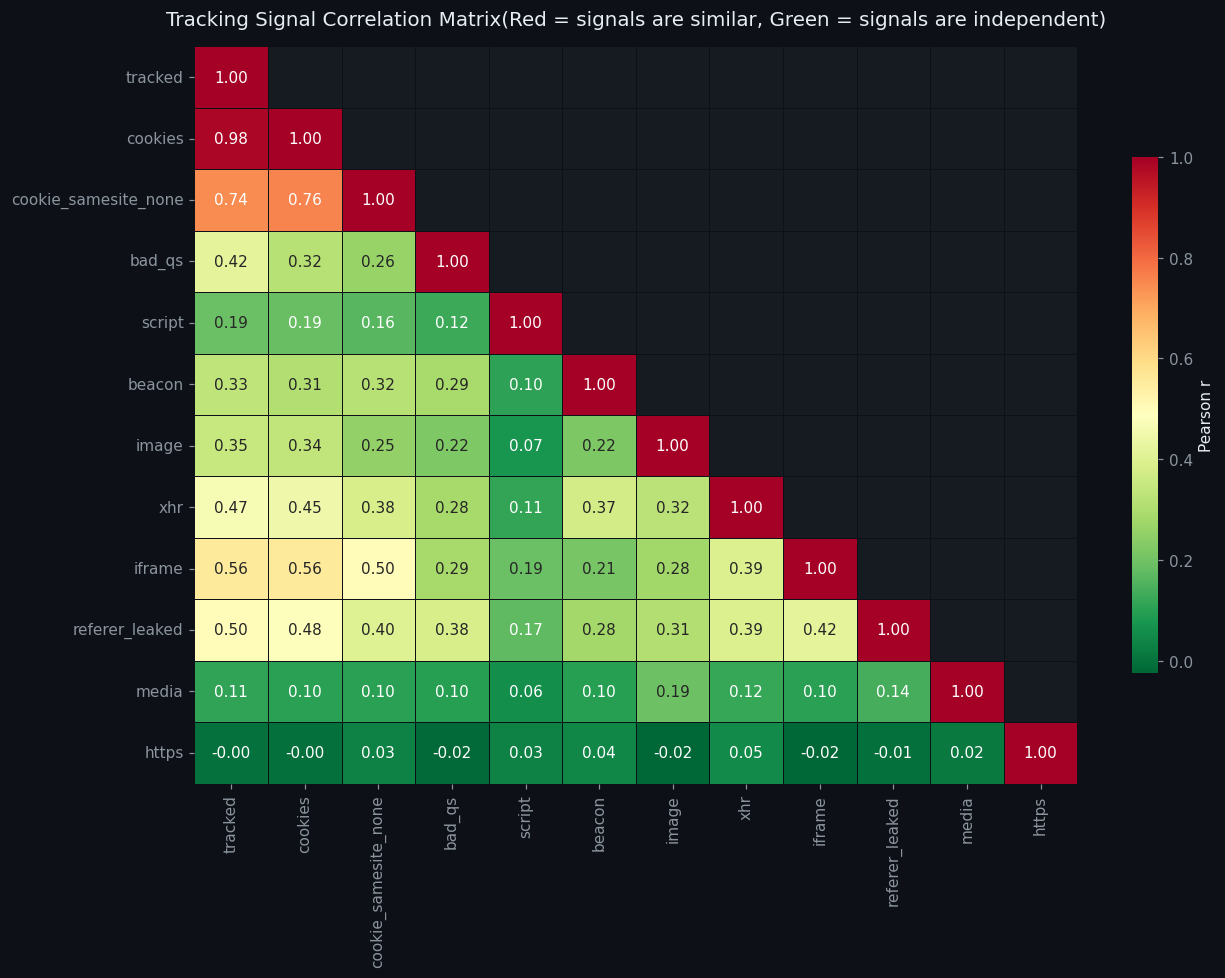

⚠️  Highly correlated pairs (r > 0.70) — watch for double-counting:
            Signal A Signal B      r
             cookies  tracked 0.9840
cookie_samesite_none  cookies 0.7570
cookie_samesite_none  tracked 0.7450


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.1 — Correlation Heatmap
#
# This shows how much each pair of signals move together.
#   +1.0 = always go up/down together (perfectly correlated)
#    0.0 = completely independent
#   -1.0 = when one goes up, the other goes down
#
# WHY IT MATTERS FOR OUR SCORE:
# If two signals are nearly identical (r > 0.9), we don't need both —
# including both would unfairly double-count the same behaviour.
# ─────────────────────────────────────────────────────────────────────────────

# Pick only the tracking signal columns for the correlation matrix
signal_cols = [c for c in SIGNAL_COLS if c in df.columns]
corr = df[signal_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))

# Only show the lower triangle (upper is a mirror — redundant)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr,
    mask       = mask,
    annot      = True,
    fmt        = ".2f",
    cmap       = "RdYlGn_r",        # red = high correlation, green = low
    linewidths = 0.5,
    linecolor  = "#0d1117",
    cbar_kws   = {"shrink": 0.7, "label": "Pearson r"},
    ax         = ax,
)

ax.set_title("Tracking Signal Correlation Matrix"
             "(Red = signals are similar, Green = signals are independent)",
             fontsize=13, pad=14, color="#e6edf3")
plt.tight_layout()
plt.show()

# Print pairs with very high correlation — candidates for redundancy
print("⚠️  Highly correlated pairs (r > 0.70) — watch for double-counting:")
strong = (
    corr.stack()
    .reset_index()
    .rename(columns={"level_0": "Signal A", "level_1": "Signal B", 0: "r"})
    .query("`Signal A` < `Signal B` and r > 0.70")
    .sort_values("r", ascending=False)
)
if strong.empty:
    print("   None found — all signals are reasonably independent!")
else:
    print(strong.round(3).to_string(index=False))


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 POPULARITY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean   : 0.0006   |   Median : 0.0001
  Min    : 0.0001   |   Max    : 1.0000
  Std    : 0.0121   |   Skew   : 65.87
  💡  Highly skewed right — most sites have low values, a few have very high


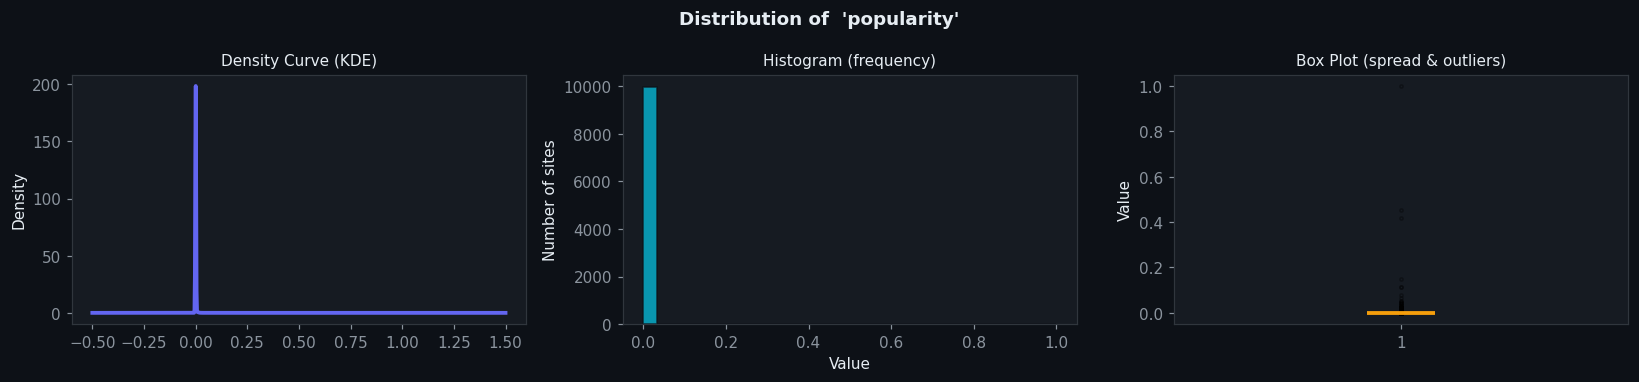

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 COOKIES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean   : 0.3925   |   Median : 0.3225
  Min    : 0.0000   |   Max    : 1.0000
  Std    : 0.3075   |   Skew   : 0.44


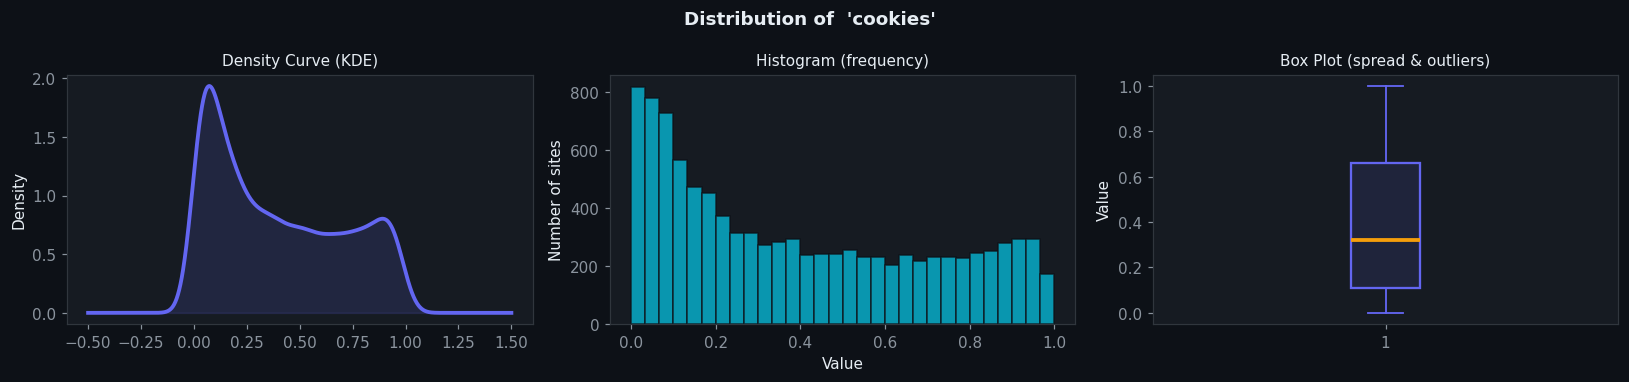

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 BAD_QS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean   : 0.0748   |   Median : 0.0285
  Min    : 0.0000   |   Max    : 0.9959
  Std    : 0.1240   |   Skew   : 3.17
  💡  Highly skewed right — most sites have low values, a few have very high


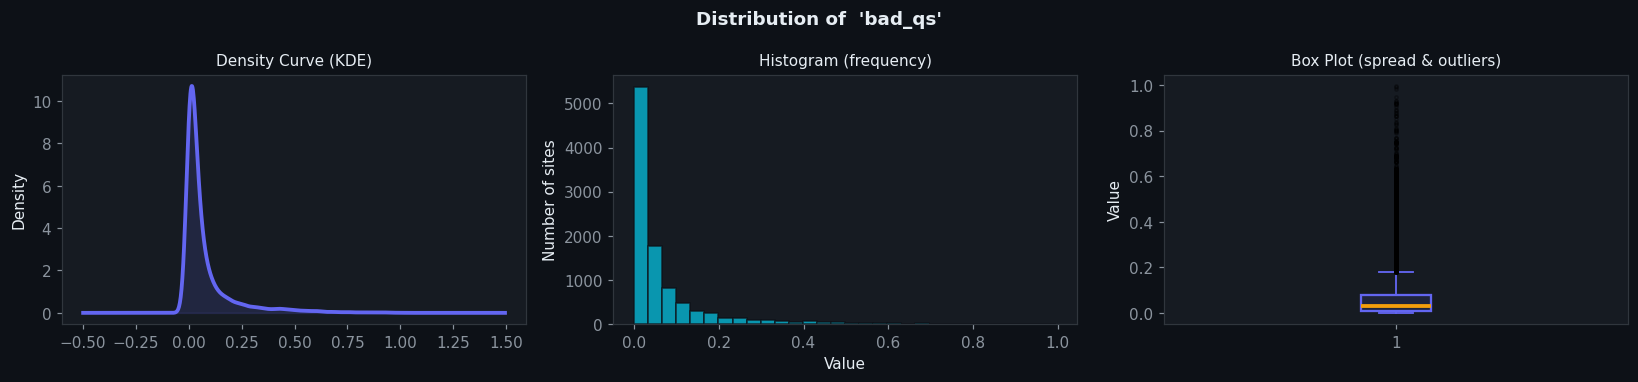

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 TRACKED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean   : 0.4109   |   Median : 0.3523
  Min    : 0.0000   |   Max    : 1.0000
  Std    : 0.3077   |   Skew   : 0.38


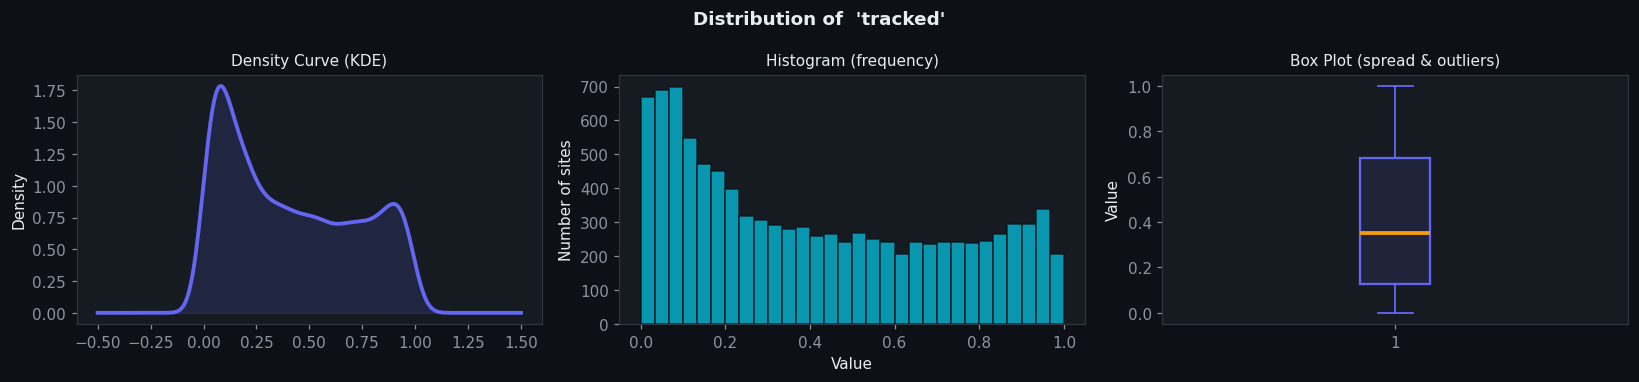

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 HTTPS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean   : 0.9959   |   Median : 0.9999
  Min    : 0.0000   |   Max    : 1.0000
  Std    : 0.0540   |   Skew   : -16.82
  💡  Highly skewed left — most sites have low values, a few have very high


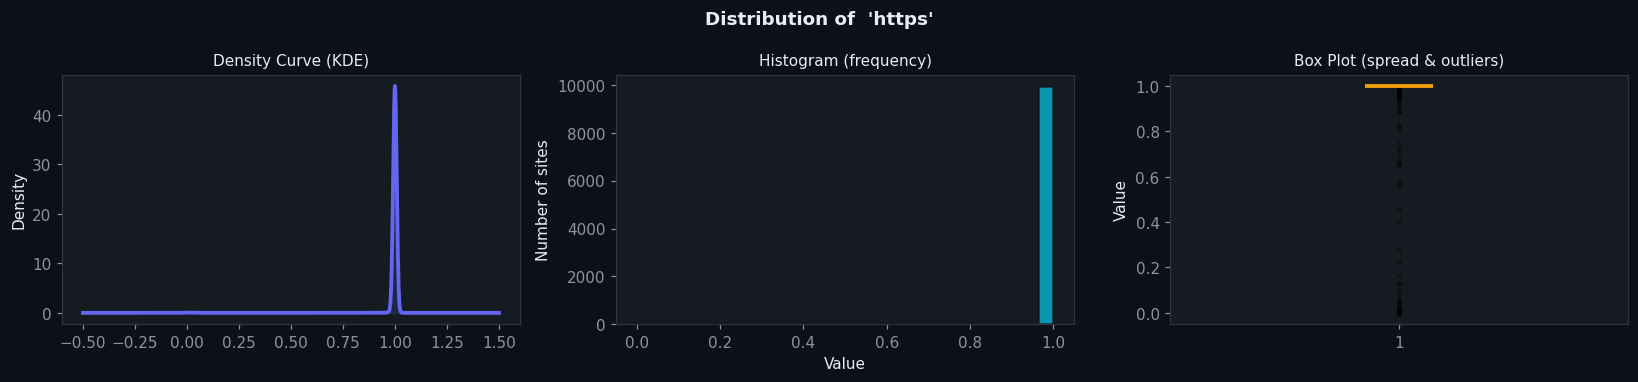

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 REQUESTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean   : 93.3371   |   Median : 39.4454
  Min    : 1.0025   |   Max    : 22162.0623
  Std    : 353.7346   |   Skew   : 32.50
  💡  Highly skewed right — most sites have low values, a few have very high


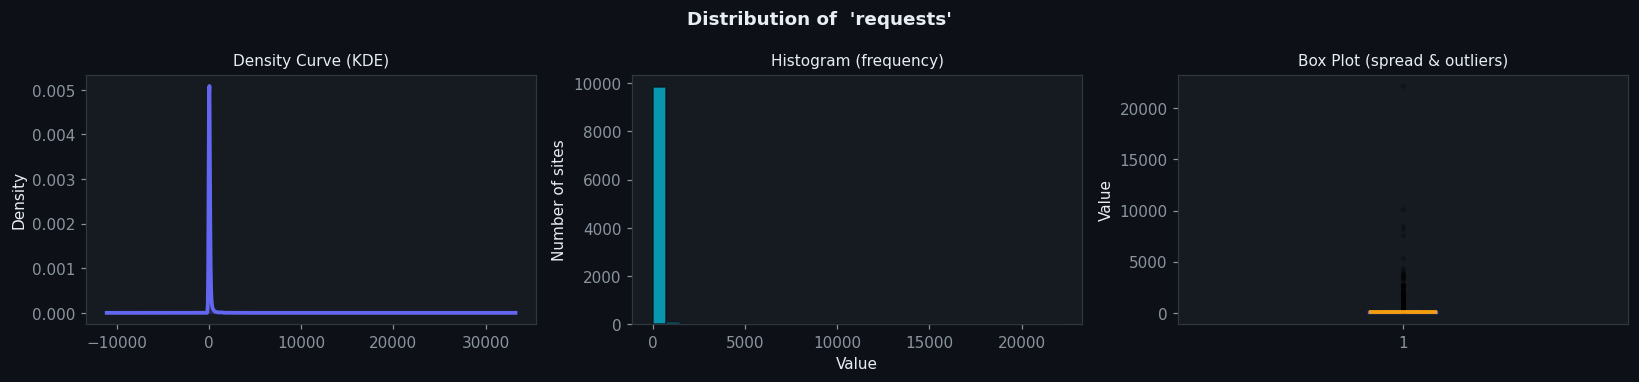

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 REQUESTS_TRACKING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean   : 9.4985   |   Median : 3.7296
  Min    : 0.0000   |   Max    : 849.9102
  Std    : 21.7834   |   Skew   : 11.72
  💡  Highly skewed right — most sites have low values, a few have very high


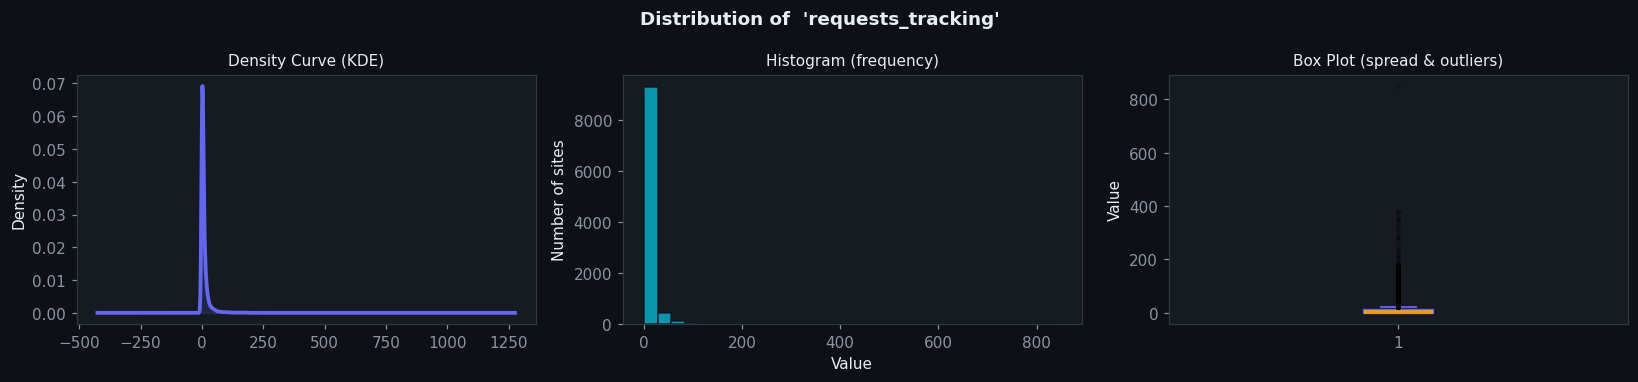

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 SCRIPT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean   : 0.9156   |   Median : 0.9706
  Min    : 0.0000   |   Max    : 1.0000
  Std    : 0.1659   |   Skew   : -3.68
  💡  Highly skewed left — most sites have low values, a few have very high


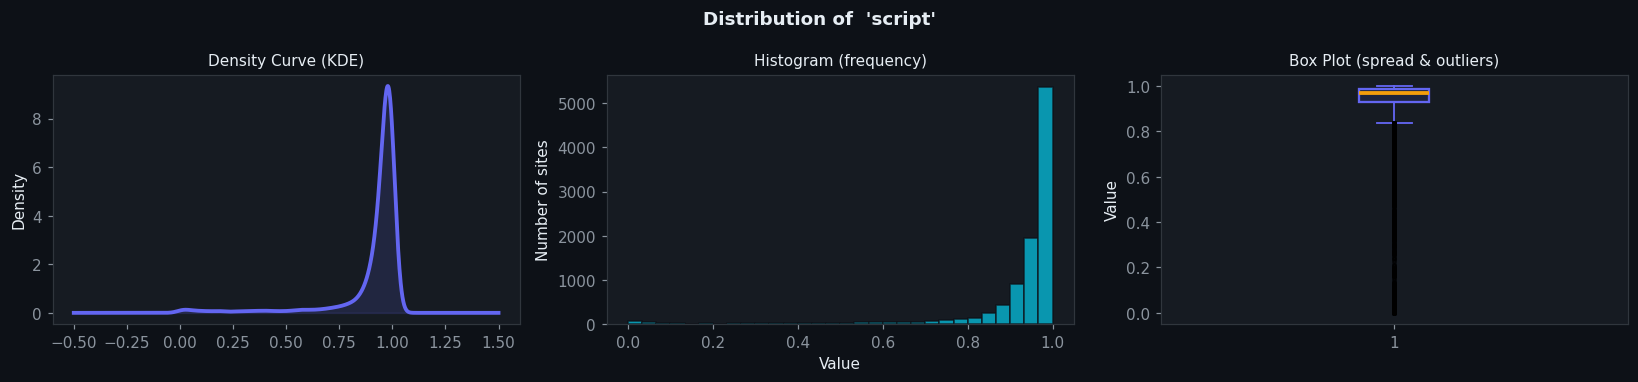

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 IFRAME
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean   : 0.3542   |   Median : 0.2301
  Min    : 0.0000   |   Max    : 1.0000
  Std    : 0.3264   |   Skew   : 0.61


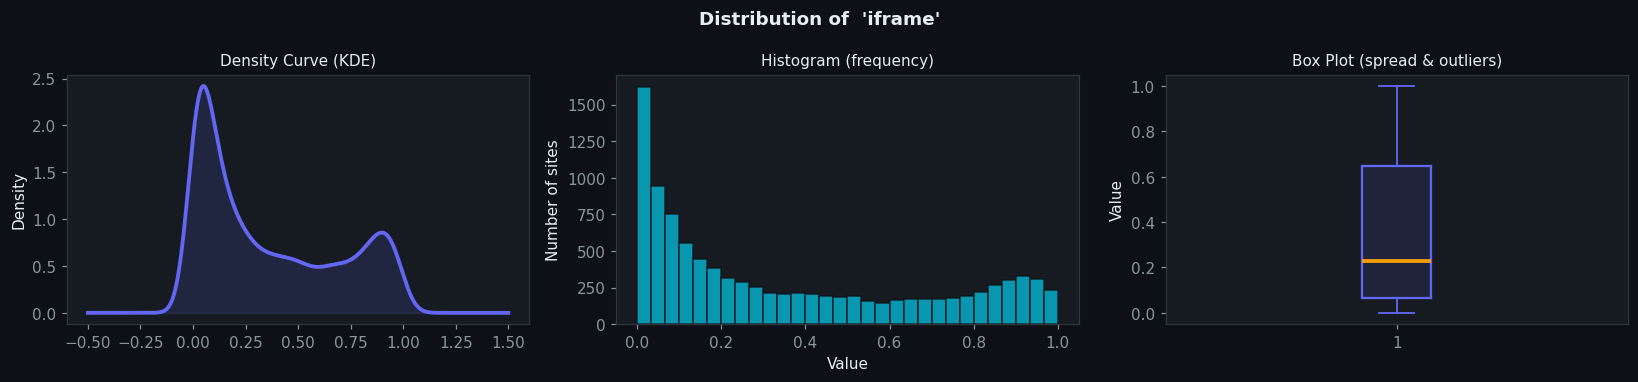

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 BEACON
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean   : 0.1714   |   Median : 0.0667
  Min    : 0.0000   |   Max    : 0.9984
  Std    : 0.2356   |   Skew   : 1.86
  💡  Highly skewed right — most sites have low values, a few have very high


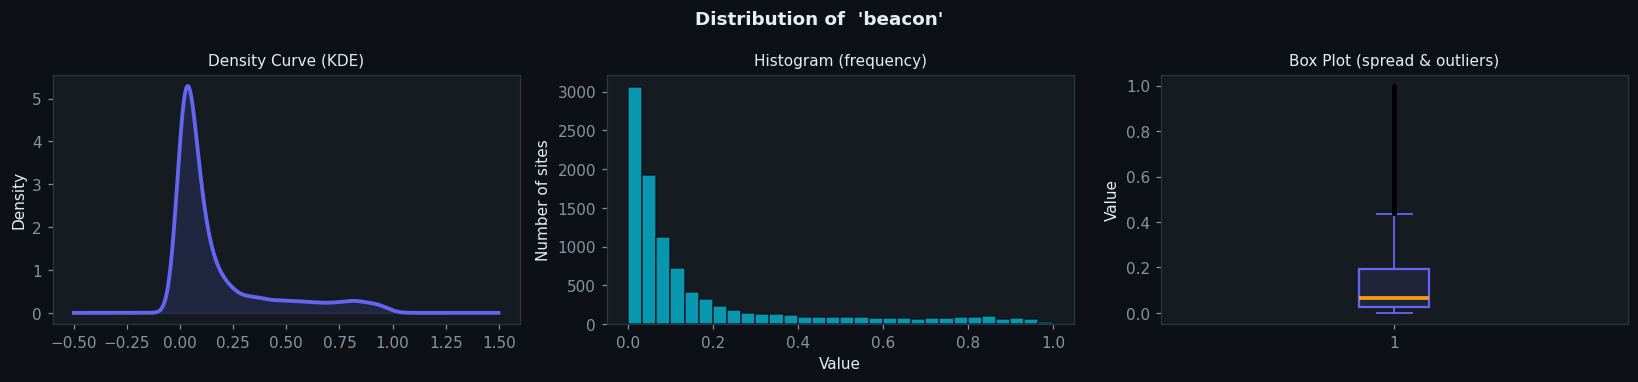

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 IMAGE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean   : 0.6322   |   Median : 0.7296
  Min    : 0.0000   |   Max    : 1.0000
  Std    : 0.3332   |   Skew   : -0.51


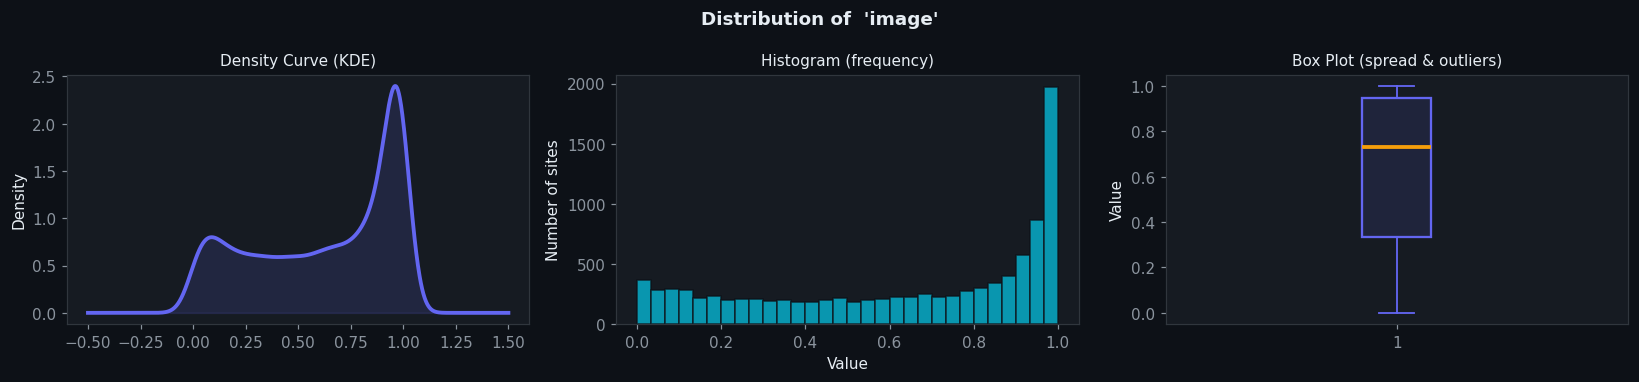

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 XHR
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean   : 0.6629   |   Median : 0.8043
  Min    : 0.0000   |   Max    : 1.0000
  Std    : 0.3348   |   Skew   : -0.60


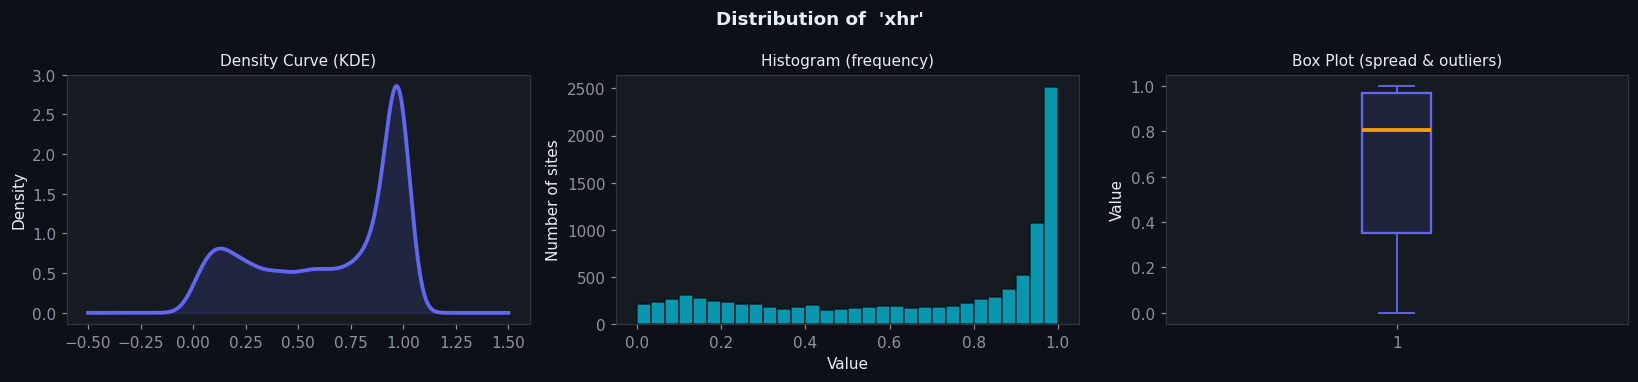

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 MEDIA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean   : 0.0676   |   Median : 0.0037
  Min    : 0.0000   |   Max    : 0.9982
  Std    : 0.1685   |   Skew   : 3.34
  💡  Highly skewed right — most sites have low values, a few have very high


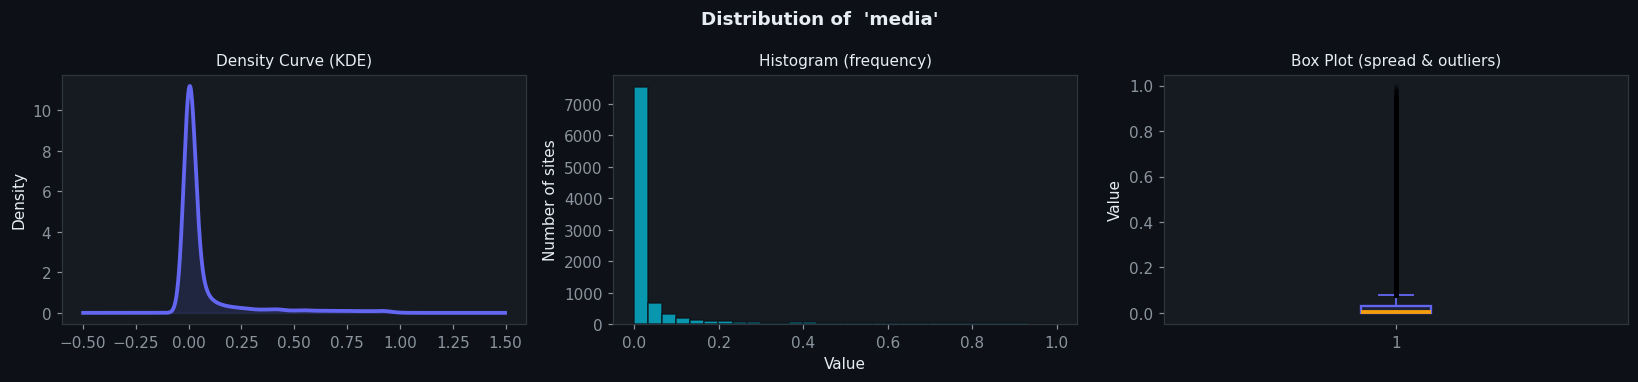

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 REFERER_LEAKED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean   : 0.3681   |   Median : 0.2296
  Min    : 0.0000   |   Max    : 1.0000
  Std    : 0.3269   |   Skew   : 0.66


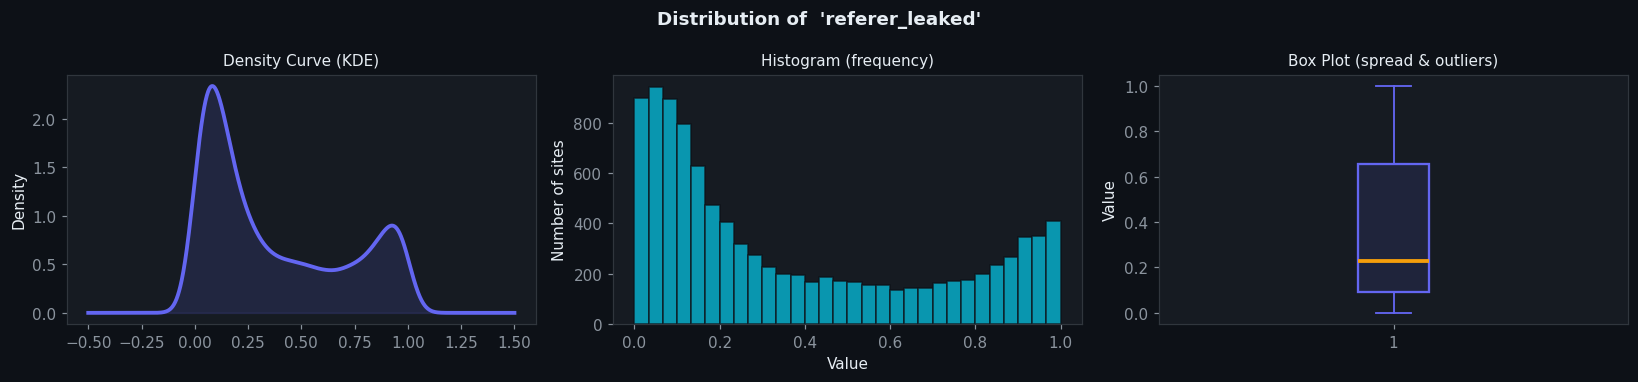

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 COOKIE_SAMESITE_NONE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean   : 0.2189   |   Median : 0.1070
  Min    : 0.0000   |   Max    : 0.9999
  Std    : 0.2529   |   Skew   : 1.36
  💡  Highly skewed right — most sites have low values, a few have very high


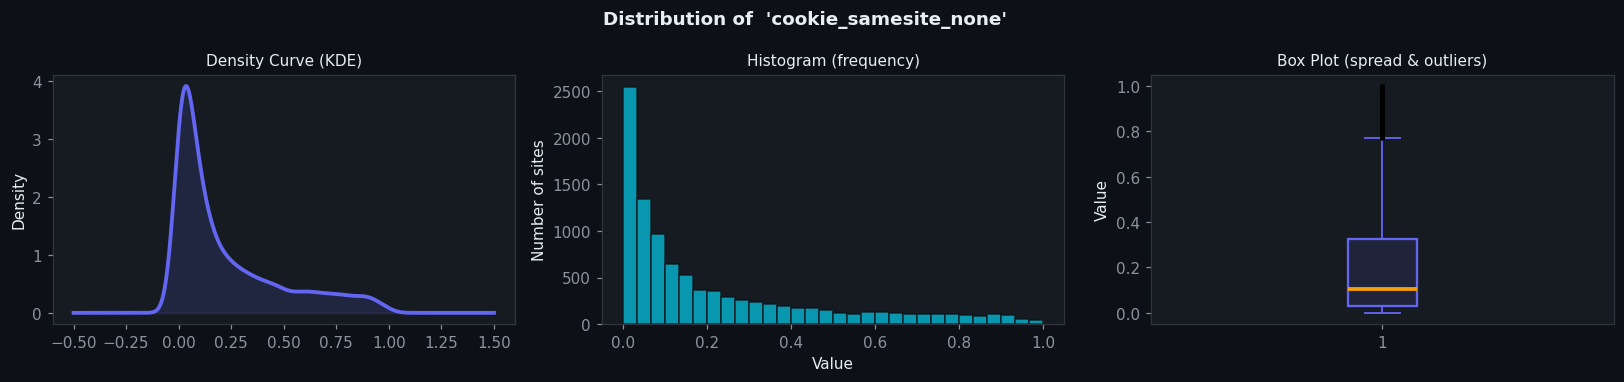

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 HOSTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean   : 7.6526   |   Median : 6.1422
  Min    : 1.0000   |   Max    : 109.2035
  Std    : 5.6554   |   Skew   : 2.51
  💡  Highly skewed right — most sites have low values, a few have very high


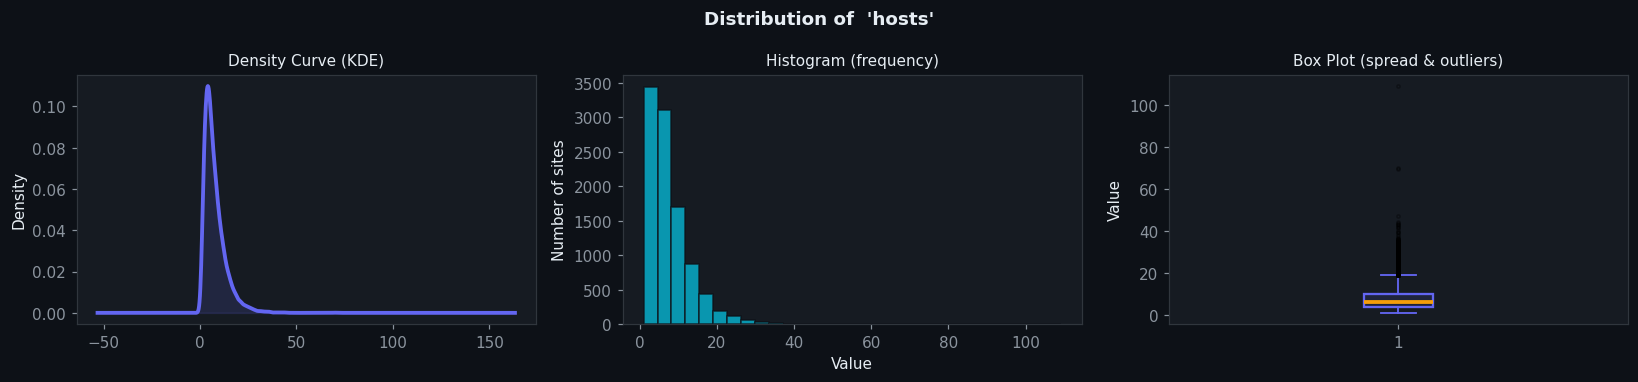

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 TRACKERS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean   : 5.9437   |   Median : 4.8643
  Min    : 1.0000   |   Max    : 51.6286
  Std    : 4.1103   |   Skew   : 2.01
  💡  Highly skewed right — most sites have low values, a few have very high


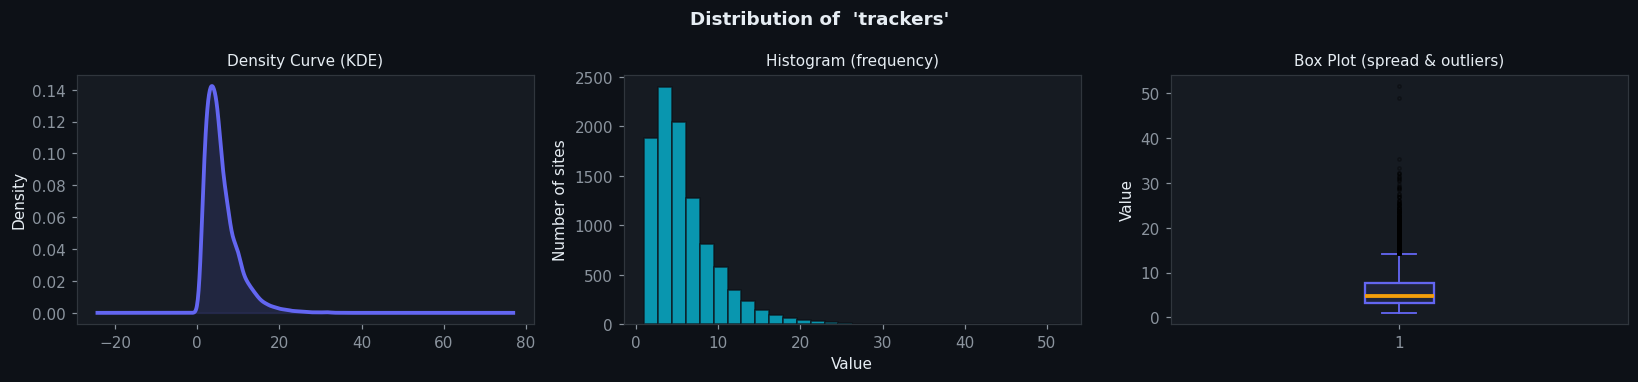

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📌 COMPANIES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Mean   : 4.5239   |   Median : 3.6907
  Min    : 1.0000   |   Max    : 39.7030
  Std    : 3.2024   |   Skew   : 2.27
  💡  Highly skewed right — most sites have low values, a few have very high


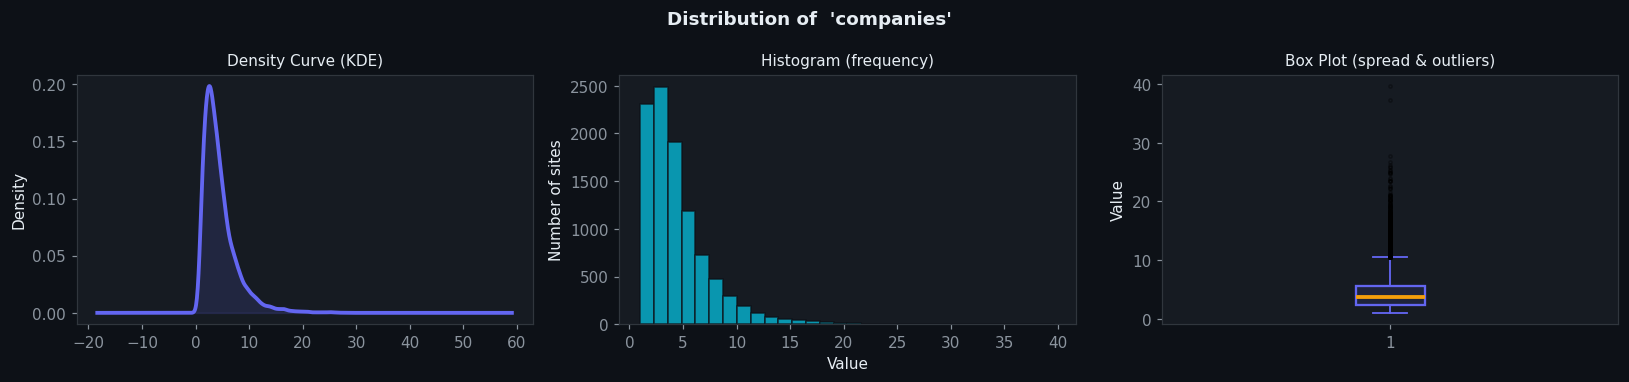

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.2 — Distribution plots for every numeric column
#
# For each column we draw three views:
#   LEFT   → KDE (smooth curve showing the "shape" of the data)
#   MIDDLE → Histogram (how many sites fall into each bucket)
#   RIGHT  → Box plot (shows median, spread, and outliers)
#
# What to look for:
#   • Is most of the data near 0? (most sites don't use this method much)
#   • Is it uniform (spread evenly)? 
#   • Are there extreme outliers?
# ─────────────────────────────────────────────────────────────────────────────

numeric_cols = df.select_dtypes(include=["float64", "float32", "int64", "int32"]).columns

for col in numeric_cols:
    series = df[col].dropna()

    # Print a quick text summary first
    print(f"{'━' * 60}")
    print(f"  📌 {col.upper()}")
    print(f"{'━' * 60}")
    print(f"  Mean   : {series.mean():.4f}   |   Median : {series.median():.4f}")
    print(f"  Min    : {series.min():.4f}   |   Max    : {series.max():.4f}")
    print(f"  Std    : {series.std():.4f}   |   Skew   : {series.skew():.2f}")
    if abs(series.skew()) > 1:
        direction = "right" if series.skew() > 0 else "left"
        print(f"  💡  Highly skewed {direction} — most sites have low values, a few have very high")

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    fig.suptitle(f"Distribution of  '{col}'", fontsize=12,
                 color="#e6edf3", fontweight="bold")

    # ── KDE curve ──
    if series.nunique() > 1:
        series.plot(kind="kde", ax=axes[0], color="#6366f1", linewidth=2.5)
        axes[0].fill_between(
            axes[0].lines[0].get_xdata(),
            axes[0].lines[0].get_ydata(),
            alpha=0.15, color="#6366f1"
        )
        axes[0].set_title("Density Curve (KDE)", fontsize=10)
    else:
        axes[0].text(0.5, 0.5, "Constant value(same for all rows)",
                     ha="center", va="center", transform=axes[0].transAxes,
                     color="#8b949e", fontsize=10)
        axes[0].set_title("KDE — skipped (constant)", fontsize=10)

    # ── Histogram ──
    series.plot(kind="hist", ax=axes[1], bins=30,
                color="#06b6d4", edgecolor="#0d1117", alpha=0.8)
    axes[1].set_title("Histogram (frequency)", fontsize=10)
    axes[1].set_xlabel("Value")
    axes[1].set_ylabel("Number of sites")

    # ── Box plot ──
    axes[2].boxplot(
        series, vert=True, patch_artist=True,
        boxprops    = dict(facecolor="#6366f120", color="#6366f1", linewidth=1.5),
        medianprops = dict(color="#f59e0b", linewidth=2.5),
        whiskerprops= dict(color="#6366f1", linewidth=1.2),
        capprops    = dict(color="#6366f1", linewidth=1.2),
        flierprops  = dict(marker=".", color="#f43f5e", alpha=0.35, markersize=4),
    )
    axes[2].set_title("Box Plot (spread & outliers)", fontsize=10)
    axes[2].set_ylabel("Value")

    plt.tight_layout()
    plt.show()


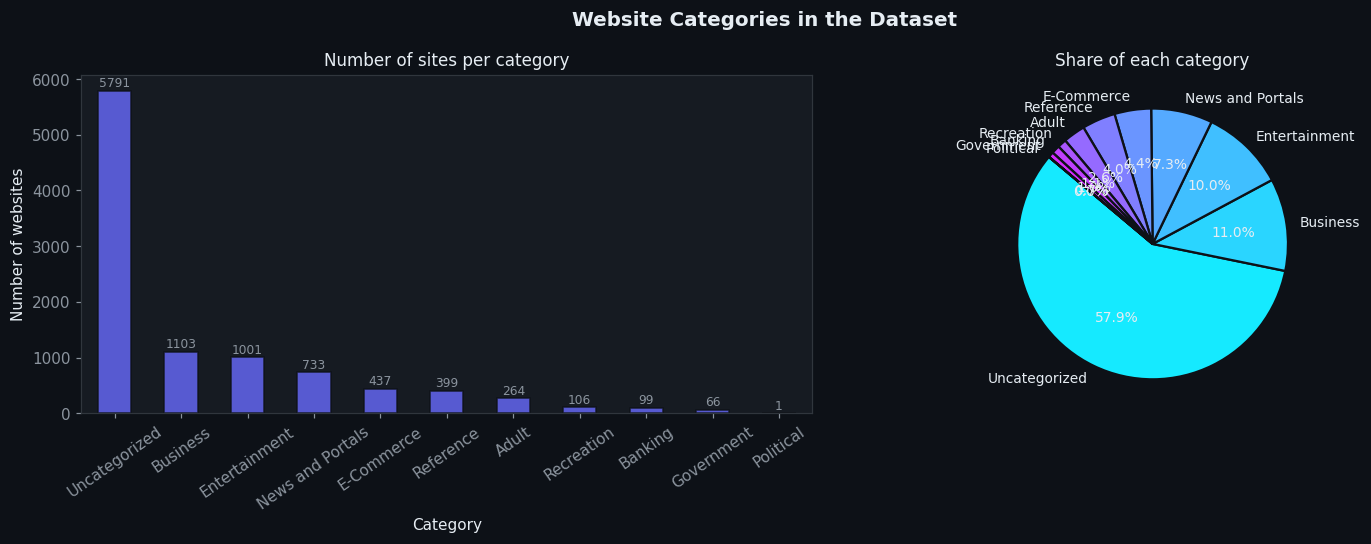

📊  Category breakdown:
  Uncategorized           5,791  (57.9%)  ████████████████████████████
  Business                1,103  (11.0%)  █████
  Entertainment           1,001  (10.0%)  █████
  News and Portals          733  (7.3%)  ███
  E-Commerce                437  (4.4%)  ██
  Reference                 399  (4.0%)  █
  Adult                     264  (2.6%)  █
  Recreation                106  (1.1%)  
  Banking                    99  (1.0%)  
  Government                 66  (0.7%)  
  Political                   1  (0.0%)  


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.3 — Distribution of website categories
#
# How many sites are in each category?
# This tells us whether the dataset is balanced or skewed toward certain types.
# ─────────────────────────────────────────────────────────────────────────────

cat_counts = df["category"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Website Categories in the Dataset", fontsize=13,
             color="#e6edf3", fontweight="bold")

# Bar chart — easy to compare counts
cat_counts.plot(kind="bar", ax=axes[0],
                color="#6366f1", edgecolor="#0d1117", alpha=0.85)
axes[0].set_title("Number of sites per category", fontsize=11)
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Number of websites")
axes[0].tick_params(axis="x", rotation=35)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 str(int(bar.get_height())),
                 ha="center", va="bottom", fontsize=8, color="#8b949e")

# Pie chart — proportion view
colors = sns.color_palette("cool", len(cat_counts))
axes[1].pie(cat_counts, labels=cat_counts.index, autopct="%.1f%%",
            colors=colors, startangle=140,
            textprops={"fontsize": 9, "color": "#e6edf3"},
            wedgeprops={"edgecolor": "#0d1117", "linewidth": 1.5})
axes[1].set_title("Share of each category", fontsize=11)

plt.tight_layout()
plt.show()

print("📊  Category breakdown:")
for cat, cnt in cat_counts.items():
    pct = cnt / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"  {cat:<22}  {cnt:>5,}  ({pct:.1f}%)  {bar}")


📊  Average tracking intensity by category (0 = none, 1 = max):
                  script    xhr  cookie_samesite_none  beacon  iframe  referer_leaked
category                                                                             
Recreation        0.9580 0.8120                0.2560  0.1710  0.3330          0.3280
News and Portals  0.9550 0.7980                0.3100  0.2700  0.4780          0.6630
E-Commerce        0.9400 0.7670                0.2420  0.2330  0.3810          0.3830
Banking           0.7820 0.7440                0.1760  0.1730  0.2980          0.2770
Business          0.9150 0.7420                0.2300  0.1850  0.3560          0.3400
Political         0.9760 0.7030                0.4060  0.1140  0.6390          0.4870
Entertainment     0.9390 0.6460                0.2250  0.1650  0.3510          0.4200
Uncategorized     0.9090 0.6400                0.2100  0.1620  0.3460          0.3400
Reference         0.9020 0.5720                0.2010  0.1130  0.2890        

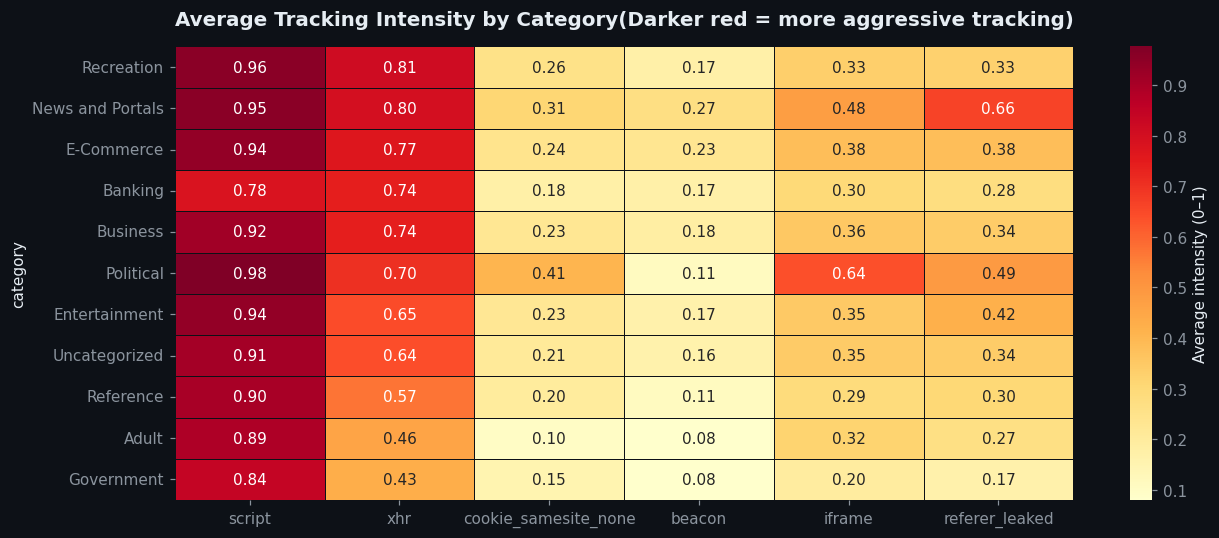

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.4 — Which categories track users the most?
#
# We group all websites by their category and calculate the average value
# of each tracking signal per category.
#
# This answers: "Do News websites track more than Banking websites?"
# ─────────────────────────────────────────────────────────────────────────────

key_signals = [c for c in ["script", "xhr", "cookie_samesite_none",
                             "beacon", "iframe", "referer_leaked"]
               if c in df.columns]

# Calculate mean tracking intensity per category
cat_profile = (
    df.groupby("category")[key_signals]
    .mean()
    .sort_values("xhr", ascending=False)   # sort by XHR — a strong signal
    .round(3)
)

print("📊  Average tracking intensity by category (0 = none, 1 = max):")
print(cat_profile.to_string())

# Heatmap — easier to read than a table of numbers
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    cat_profile,
    annot      = True,
    fmt        = ".2f",
    cmap       = "YlOrRd",             # yellow = low, red = high
    linewidths = 0.5,
    linecolor  = "#0d1117",
    ax         = ax,
    cbar_kws   = {"label": "Average intensity (0–1)"},
)
ax.set_title("Average Tracking Intensity by Category"
    "(Darker red = more aggressive tracking)",
    fontsize=13, pad=14, color="#e6edf3", fontweight="bold"
)
ax.set_xlabel("")
plt.tight_layout()
plt.show()


---

## 🧮 Step 6 — Build the Privacy Score Formula

### The big question: *How do we turn 10+ columns into one meaningful score?*

We'll use a **weighted formula** — not machine learning.

**Why not machine learning?**
- We have no "ground truth" labels (no one has rated all 10,000 sites as "good" or "bad")
- A transparent formula is easier to explain and trust
- We understand exactly why each signal matters

---

### 🔑 The core idea: tracking needs TWO things to happen

A website that runs JavaScript (`script`) isn't automatically a tracker.  
A website that makes background requests (`xhr`) isn't automatically a tracker.  
But a website that does **both at the same time**? That's tracking you.

So our main signal is:

```
core_signal = √(script × xhr)
```

This is the **geometric mean** — it's only high when BOTH values are high.

---

### 🔗 Interaction terms: when two bad things happen together

We also create **interaction terms** to capture dangerous combos:

| Term | Formula | Meaning |
|------|---------|---------|
| `it1` | `cookie_samesite_none × core_signal` | Identity tracking + behavioural monitoring |
| `it2` | `script × xhr` | Raw session tracking (same as core, used again to boost weight) |
| `it3` | `iframe × core_signal` | Hidden embeds + active data exfiltration |

---

### ⚖️ Final weights

```
Privacy Score =
    core_signal           × 0.50   ← most important signal
    + it2 (script × xhr)  × 0.30   ← raw tracking intensity
    + referer_leaked       × 0.10   ← browsing history exposed
    + it3 (iframe combo)  × 0.10
    + it1 (cookie combo)  × 0.05
    + cookie_samesite_none × 0.03
    + iframe               × 0.03
    + beacon               × 0.02   ← least common but very invasive

Then divide by the sum of weights and multiply by 100 → score between 0 and 100
```


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Privacy Score Formula — Version 1 (Baseline)
#
# Simple version with just the core signal and 4 supporting signals.
# We'll compare this to Version 2 to see how much interaction terms help.
# ─────────────────────────────────────────────────────────────────────────────

def compute_privacy_score_v1(df):
    """
    Baseline privacy score.

    Core idea: use geometric mean of script × xhr as the main signal.
    High scores mean the site is actively running code AND sending data home.

    Returns a copy of the dataframe with a new 'privacy_score' column.
    """
    d = df.copy()

    # Core signal: geometric mean of script and XHR
    # √(a × b) is only high when BOTH a and b are high
    d["sgeo"] = np.sqrt(d["script"] * d["xhr"])

    # Each signal gets a weight reflecting how much we trust it as a privacy risk
    WEIGHTS = {
        "sgeo"               : 0.70,   # most important — confirmed tracking
        "cookie_samesite_none": 0.10,  # cross-site cookies
        "iframe"             : 0.05,   # hidden embeds
        "referer_leaked"     : 0.05,   # browsing history exposed
        "beacon"             : 0.02,   # silent exit pings
    }

    total_weight = sum(WEIGHTS.values())   # = 0.92

    # Weighted sum, normalized to 0–100
    d["privacy_score"] = (
        sum(d[col] * weight for col, weight in WEIGHTS.items())
    ) / total_weight * 100

    # Round and clip to keep values clean
    d["privacy_score"] = d["privacy_score"].clip(0, 100).round(2)
    return d


# Run it and preview results
df_v1 = compute_privacy_score_v1(df)

print("📊  V1 Score Distribution:")
print(df_v1["privacy_score"].describe().round(2))
print()
print("🔍  Sample scores:")
sample = df_v1[["site", "category", "privacy_score"]].sample(10, random_state=SEED)
print(sample.to_string(index=False))


📊  V1 Score Distribution:
count   10000.0000
mean       62.7700
std        23.2800
min         0.0000
25%        45.0300
50%        70.7000
75%        80.8600
max        99.9500
Name: privacy_score, dtype: float64

🔍  Sample scores:
             site         category  privacy_score
  jobbmintatv.pro    Uncategorized        86.8900
       win2day.at    Entertainment        64.1800
         csod.com         Business        68.1500
       diablo2.io    Uncategorized        76.7400
          maif.fr         Business        32.9500
     enterjoy.day    Uncategorized        12.5900
   infoseek.co.jp News and Portals        92.3000
notebookcheck.com    Entertainment        83.6100
       uaudio.com    Uncategorized        85.7600
       iheart.com    Entertainment        87.0900


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Privacy Score Formula — Version 2 (Final)
#
# Adds interaction terms on top of V1.
#
# Interaction terms capture the "1 + 1 = 3" effect:
# A site using cookies AND running scripts is worse than the sum of its parts.
# ─────────────────────────────────────────────────────────────────────────────

def compute_privacy_score_v2(df):
    """
    Final privacy score with interaction terms.

    Interaction terms added:
      it1 = cookie_samesite_none × sgeo  →  identity tracking + behavioural
      it2 = script × xhr                 →  raw session tracking
      it3 = iframe × sgeo                →  embed surveillance + data exfil

    Returns a copy of the dataframe with sgeo, it1, it2, it3, privacy_score.
    """
    d = df.copy()

    # ── Step 1: Compute the core signal ─────────────────────────────────────
    # Geometric mean — only high when BOTH script and xhr are high
    d["sgeo"] = np.sqrt(d["script"] * d["xhr"])

    # ── Step 2: Compute interaction terms ────────────────────────────────────
    # These capture "multi-method" tracking — more dangerous than single signals
    d["it1"] = d["cookie_samesite_none"] * d["sgeo"]   # identity × behavioral
    d["it2"] = d["script"]              * d["xhr"]     # session tracking intensity
    d["it3"] = d["iframe"]              * d["sgeo"]    # embed × core

    # ── Step 3: Weighted sum ──────────────────────────────────────────────────
    WEIGHTS = {
        "sgeo"               : 0.50,   # core tracking signal (highest weight)
        "it2"                : 0.30,   # raw script × xhr combo
        "referer_leaked"     : 0.10,   # browsing history exposed
        "it3"                : 0.10,   # iframe surveillance combo
        "it1"                : 0.05,   # cookie + behavioral combo
        "cookie_samesite_none": 0.03,  # cross-site cookies alone
        "iframe"             : 0.03,   # hidden embeds alone
        "beacon"             : 0.02,   # silent exit pings
    }

    total_weight = sum(WEIGHTS.values())   # = 1.13

    d["privacy_score"] = (
        sum(d[col] * weight for col, weight in WEIGHTS.items())
    ) / total_weight * 100

    d["privacy_score"] = d["privacy_score"].clip(0, 100).round(2)
    return d


# Run it
df_v2 = compute_privacy_score_v2(df)

print("📊  V2 Score Distribution:")
print(df_v2["privacy_score"].describe().round(2))


📊  V2 Score Distribution:
count   10000.0000
mean       57.4500
std        25.1000
min         0.0000
25%        36.0500
50%        64.6600
75%        77.6600
max        99.9400
Name: privacy_score, dtype: float64


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Compare V1 vs V2 — did the interaction terms change anything meaningful?
# ─────────────────────────────────────────────────────────────────────────────

comparison = pd.DataFrame({
    "site"       : df_v2["site"],
    "v1_score"   : df_v1["privacy_score"],
    "v2_score"   : df_v2["privacy_score"],
    "difference" : (df_v2["privacy_score"] - df_v1["privacy_score"]).round(2),
})

print("📈  How much did V2 change scores compared to V1?")
print(f"   Average change  : +{comparison['difference'].mean():.2f} points")
print(f"   Max change      : +{comparison['difference'].max():.2f} points")
print(f"   Sites unchanged :  {(comparison['difference'] == 0).sum():,}")

print("
🔴  Sites most boosted by interaction terms (multi-method trackers):")
print(comparison.nlargest(10, "difference").to_string(index=False))


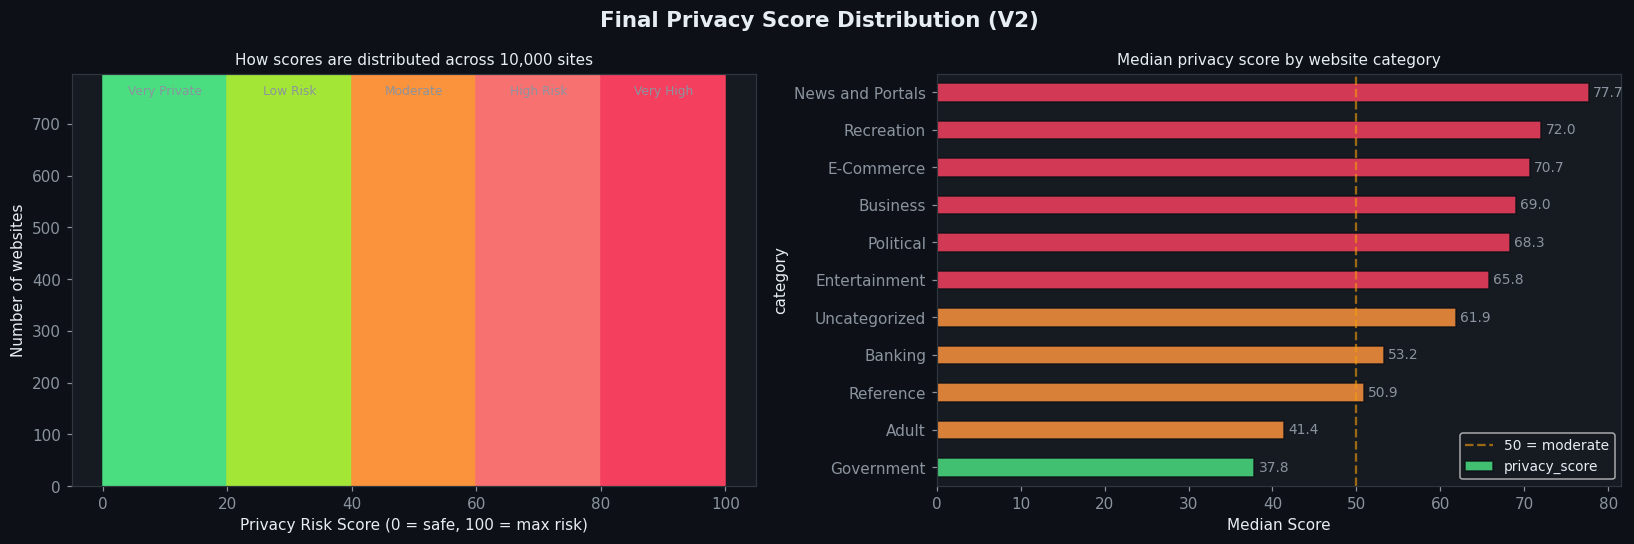

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualise the final scores
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Final Privacy Score Distribution (V2)", fontsize=14,
             color="#e6edf3", fontweight="bold")

# ── Left: Overall score histogram ────────────────────────────────────────────
axes[0].hist(df_v2["privacy_score"], bins=30,
             color="#6366f1", edgecolor="#0d1117", alpha=0.85)

# Add risk zone shading
for zone_start, zone_end, color, label in [
    (0,  20, "#4ade8020", "Very Private"),
    (20, 40, "#a3e63520", "Low Risk"),
    (40, 60, "#fb923c20", "Moderate"),
    (60, 80, "#f8717120", "High Risk"),
    (80,100, "#f43f5e20", "Very High"),
]:
    axes[0].axvspan(zone_start, zone_end, alpha=1, color=color)
    axes[0].text((zone_start + zone_end) / 2, axes[0].get_ylim()[1] * 0.95,
                label, ha="center", fontsize=8, color="#8b949e")

axes[0].set_title("How scores are distributed across 10,000 sites", fontsize=10)
axes[0].set_xlabel("Privacy Risk Score (0 = safe, 100 = max risk)")
axes[0].set_ylabel("Number of websites")

# ── Right: Median score by category ──────────────────────────────────────────
cat_scores = df_v2.groupby("category")["privacy_score"].median().sort_values()
colors_bar = ["#4ade80" if v < 40 else "#fb923c" if v < 65 else "#f43f5e"
              for v in cat_scores]

cat_scores.plot(kind="barh", ax=axes[1], color=colors_bar,
                edgecolor="#0d1117", alpha=0.85)
axes[1].set_title("Median privacy score by website category", fontsize=10)
axes[1].set_xlabel("Median Score")
axes[1].axvline(50, color="#f59e0b", linestyle="--", alpha=0.6, label="50 = moderate")
axes[1].legend(fontsize=9)

# Add score labels on bars
for i, (val, cat) in enumerate(zip(cat_scores, cat_scores.index)):
    axes[1].text(val + 0.5, i, f"{val:.1f}", va="center", fontsize=9, color="#8b949e")

plt.tight_layout()
plt.show()


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Top 20 most privacy-invasive websites in the dataset
# ─────────────────────────────────────────────────────────────────────────────

top20 = (
    df_v2[["site", "category", "privacy_score"]]
    .nlargest(20, "privacy_score")
    .reset_index(drop=True)
)
top20.index += 1   # start rank from 1

print("🚨  Top 20 highest-risk websites:")
print(top20.to_string())


🚨  Top 20 highest-risk websites:
                     site       category  privacy_score
1               vendoo.co  Uncategorized        99.9400
2   correio24horas.com.br  Uncategorized        99.6800
3    doubledowncasino.com  Uncategorized        99.6100
4             fullbay.com  Uncategorized        99.3200
5            linestep.net  Uncategorized        99.2200
6         openinvoice.com  Uncategorized        98.9100
7        housecallpro.com  Uncategorized        98.6700
8         womanwithin.com  Uncategorized        98.6200
9              sellsy.com  Uncategorized        98.3100
10       githubstatus.com  Uncategorized        98.2800
11            tinywow.com  Uncategorized        98.2400
12          backstage.com  Uncategorized        98.2400
13             jeu2048.fr  Uncategorized        98.2100
14       allclassical.org  Uncategorized        98.1400
15          shopcider.com  Uncategorized        98.0300
16     thereformation.com  Uncategorized        98.0200
17           mi

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# Top 20 most privacy-friendly websites in the dataset
# ─────────────────────────────────────────────────────────────────────────────

bottom20 = (
    df_v2[["site", "category", "privacy_score"]]
    .nsmallest(20, "privacy_score")
    .reset_index(drop=True)
)
bottom20.index += 1

print("✅  Top 20 most privacy-friendly websites:")
print(bottom20.to_string())


✅  Top 20 most privacy-friendly websites:
                      site       category  privacy_score
1   aschenstedt.dnshome.de       Business         0.0000
2          hyperessays.com  Uncategorized         0.0000
3                 stel.com  Uncategorized         0.0000
4           shopmanager.gr  Uncategorized         0.0000
5             bidocean.com  Uncategorized         0.0000
6      blixottel.github.io  Uncategorized         0.0000
7              explorer.rs  Uncategorized         0.0000
8            yellowgrid.ro  Uncategorized         0.0000
9            quintiles.com  Uncategorized         0.0000
10            x-bridge.com  Uncategorized         0.0000
11                  qrv.jp  Uncategorized         0.0000
12             appcoll.com  Uncategorized         0.0100
13                 ax4.com  Uncategorized         0.0500
14          oekakiskey.com  Uncategorized         0.0700
15         incidenthub.net  Uncategorized         0.0800
16         ms-medicaid.com  Uncategorized     

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# Export the final scored dataset for use in the Streamlit app
# ─────────────────────────────────────────────────────────────────────────────

EXPORT_COLS = [
    "site", "category", "popularity",
    "script", "xhr", "sgeo",
    "cookie_samesite_none", "iframe", "referer_leaked", "beacon",
    "it1", "it2", "it3",
    "privacy_score",
]

# Only keep columns that exist (safe if formula wasn't run)
df_export = df_v2[[c for c in EXPORT_COLS if c in df_v2.columns]]
df_export.to_csv("whotracks_2026/sites_scored.csv", index=False)

print("💾  Final scored dataset saved → whotracks_2026/sites_scored.csv")
print(f"    Rows    : {df_export.shape[0]:,}")
print(f"    Columns : {df_export.shape[1]}")
print("✅  Ready to plug into the Streamlit app (app.py)!")


💾  Final scored dataset saved → whotracks_2026/sites_scored.csv
    Rows    : 10,000
    Columns : 14
✅  Ready to plug into the Streamlit app (app.py)!


---

## ✅ You're Done!

Here's what we accomplished in this notebook:

| Step | What we did | Key output |
|------|-------------|-----------|
| 📥 Step 1 | Downloaded real-world tracker data | `whotracks_2026/` folder |
| 🔍 Step 2 | Loaded and profiled the raw data | 10,000 rows × 32 columns |
| 📖 Step 3 | Understood every column | Keep/drop decisions documented |
| 🧹 Step 4 | Removed 11 useless columns | Clean dataset: 21 columns |
| 📊 Step 5 | Visualised distributions and correlations | Charts for every column |
| 🧮 Step 6 | Built the privacy scoring formula | `sites_scored.csv` with scores 0–100 |

---

### 🚀 Next step

Feed `sites_scored.csv` into the Streamlit app (`app.py`) to get a  
fully interactive privacy dashboard — search any website and see its score!

---

> 📌 **Quick score reading guide**
>
> | Score | Meaning |
> |-------|---------|
> | 0 – 20 | 🟢 Very Private — minimal tracking |
> | 21 – 40 | 🟡 Low Risk — standard web tracking |
> | 41 – 60 | 🟠 Moderate Risk — notable tracking |
> | 61 – 80 | 🔴 High Risk — aggressive tracking |
> | 81 – 100 | 🚨 Very High Risk — pervasive surveillance |
